In [1]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Modelos de Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
# Carga del archivo TSV
df = pd.read_csv('dataset_procesado.tsv', sep='\t')
print(f"Dataset cargado con éxito. Forma: {df.shape}")

Dataset cargado con éxito. Forma: (251827, 10)


In [3]:
# Selección de características (predictores) y variable objetivo
features = ['b02', 'b03_1', 'b04_1', 'nbr_1', 'B5', 'B6', 'B7']
X = df[features]
y = df['area_quemada']

# División en conjuntos de entrenamiento (70%) y prueba (30%)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Estandarización de variables (esencial para SVM, KNN y Red Neuronal)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

In [4]:
# Inicialización de los 5 modelos con parámetros base estables
models = {
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "SVM": LinearSVC(max_iter=1000, dual=False, random_state=42),
    "Red Neuronal": MLPClassifier(max_iter=300, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

# Diccionarios para almacenar resultados
accuracies = {}
confusion_matrices = {}

# Entrenamiento y evaluación individual
for name, model in models.items():
    print(f"Entrenando modelo: {name}...")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Cálculo de métricas
    accuracies[name] = accuracy_score(y_test, predictions)
    confusion_matrices[name] = confusion_matrix(y_test, predictions)
print("Todos los modelos han sido entrenados.")

Entrenando modelo: Árbol de Decisión...
Entrenando modelo: SVM...
Entrenando modelo: Red Neuronal...
Entrenando modelo: KNN...
Entrenando modelo: Naive Bayes...
Todos los modelos han sido entrenados.


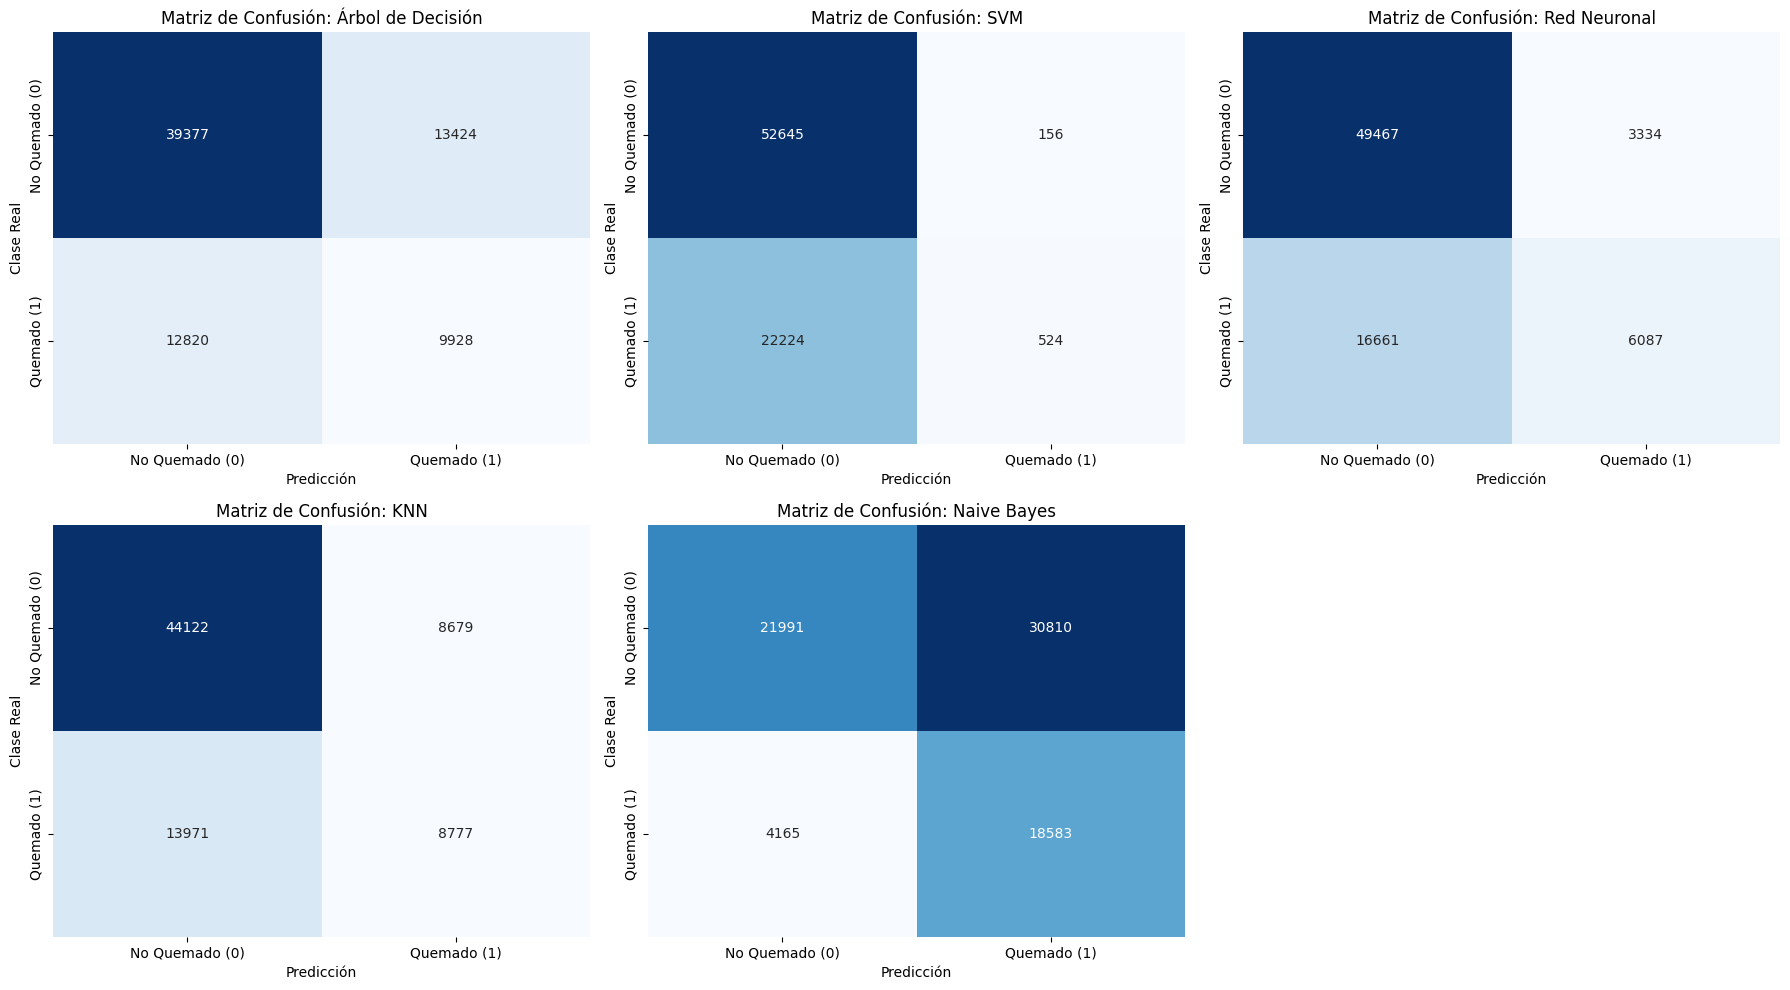

In [5]:
# Matrices de confusion
# Configuración del lienzo para las gráficas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Generación de mapas de calor para cada matriz de confusión
for idx, (name, matrix) in enumerate(confusion_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['No Quemado (0)', 'Quemado (1)'],
                yticklabels=['No Quemado (0)', 'Quemado (1)'])
    axes[idx].set_title(f"Matriz de Confusión: {name}")
    axes[idx].set_xlabel("Predicción")
    axes[idx].set_ylabel("Clase Real")

# Eliminar el último recuadro vacío del grid de 2x3
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [6]:
# Comparación de accuracy
# Creación de DataFrame comparativo
df_comparison = pd.DataFrame(list(accuracies.items()), columns=['Modelo', 'Accuracy Global'])
df_comparison['Accuracy Global'] = df_comparison['Accuracy Global'] * 100

# Ordenar de mayor a menor rendimiento
df_comparison = df_comparison.sort_values(by='Accuracy Global', ascending=False).reset_index(drop=True)

# Mostrar tabla de resultados
print("TABLA COMPARATIVA DE RENDIMIENTO")
print("=" * 40)
print(df_comparison.to_string(index=False, formatters={'Accuracy Global': '{:.2f}%'.format}))
print("=" * 40)

TABLA COMPARATIVA DE RENDIMIENTO
           Modelo Accuracy Global
     Red Neuronal          73.53%
              SVM          70.38%
              KNN          70.02%
Árbol de Decisión          65.26%
      Naive Bayes          53.71%
